# 05 — Walk-Forward LightGBM Model

We train a LightGBM ranker/regressor on the engineered feature matrix using an **expanding-window walk-forward** protocol:

```
Fold 1: train ≤ 2019-Q4  →  test 2020-Q1
Fold 2: train ≤ 2020-Q1  →  test 2020-Q2
...continuing quarterly through 2026-Q1
```

**Look-ahead audit in this notebook:**
- Hyperparameters are tuned **once** on 2010-2017 held-out data, then frozen
- `StandardScaler.fit()` + imputation is always fit on train fold only, then `.transform(test)`
- Feature selection (Spearman-MI ranking) is refit at each fold on train data only
- The model's predicted score is stored as `lgbm_pred` — never fed back as a feature

Target: **5-day forward return** (justified by the IC decay curve in notebook 04 and the ATC classifier's 14-day training window).

In [1]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_regression
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', font_scale=1.05)

PROJECT     = Path('/Users/chaithanyapakala/Downloads/NLP_FinalProject')
DATA_DIR    = PROJECT / 'data'
FEATURES_PQ = DATA_DIR / 'features.parquet'
PREDS_PQ    = DATA_DIR / 'model_predictions.parquet'
FIG_DIR     = PROJECT / 'figures'

TARGET      = 'fwd_5d'     # justified by IC decay curve
HORIZONS    = [1, 3, 5, 10, 20]
UNIVERSES   = ['in_sp500', 'in_sp1500', 'in_ru3k']

feat_df = pd.read_parquet(FEATURES_PQ)
feat_df['entry_date'] = pd.to_datetime(feat_df['entry_date'])
feat_df['DocDate']    = pd.to_datetime(feat_df['DocDate'])
print(f'Feature matrix: {feat_df.shape}')

Feature matrix: (376790, 92)


## 5.1 Feature and Walk-Forward Configuration

We define the feature set and walk-forward split dates. Hyperparameters are tuned on 2010-2017 (below), frozen, and never touched again during the test period (2020+).

In [2]:
# All engineered feature columns (exclude targets, IDs, universe flags)
NON_FEAT = [
    'DocID','BESTTICKER','DocDate','entry_date','SECTOR','QTR_YEAR',
    'in_sp500','in_sp1500','in_ru3k',
    'fwd_1d','fwd_3d','fwd_5d','fwd_10d','fwd_20d'
]
FEATURE_COLS = [c for c in feat_df.columns if c not in NON_FEAT]
print(f'Feature columns: {len(FEATURE_COLS)}')

# Walk-forward quarterly splits
# Train cutoff starts at 2019-Q4 (per handout: train end ≤ 2019)
# Each fold adds one quarter to the training set
def generate_wf_splits(df, train_end_start='2019-12-31', freq='Q'):
    """
    Yields (train_mask, test_mask) for expanding-window walk-forward.
    """
    dates = pd.date_range(start=train_end_start, end=df['entry_date'].max(), freq=freq)
    for i in range(len(dates) - 1):
        train_end  = dates[i]
        test_start = dates[i]
        test_end   = dates[i + 1]
        train_mask = df['entry_date'] <= train_end
        test_mask  = (df['entry_date'] > test_start) & (df['entry_date'] <= test_end)
        if train_mask.sum() < 1000 or test_mask.sum() < 50:
            continue
        yield train_mask, test_mask, train_end.date(), test_end.date()

splits = list(generate_wf_splits(feat_df))
print(f'Walk-forward folds: {len(splits)}')
print(f'  First fold: train to {splits[0][2]}, test {splits[0][2]} → {splits[0][3]}')
print(f'  Last  fold: train to {splits[-1][2]}, test {splits[-1][2]} → {splits[-1][3]}')

Feature columns: 78
Walk-forward folds: 25
  First fold: train to 2019-12-31, test 2019-12-31 → 2020-03-31
  Last  fold: train to 2025-12-31, test 2025-12-31 → 2026-03-31


## 5.2 Hyperparameter Tuning (2010-2017 held-out only)

We tune once on 2010-2017, freeze the params, and never retune. This prevents hyperparameter look-ahead leakage (if you grid-search on the full sample then rerun, you've leaked).

In [3]:
# Tuning period: 2010-2017
tune_mask   = feat_df['entry_date'].between('2010-01-01','2017-12-31')
tune_data   = feat_df[tune_mask].dropna(subset=[TARGET])

X_tune = tune_data[FEATURE_COLS].fillna(0)
y_tune = tune_data[TARGET]

# Simple coarse grid (3×3 = 9 combos — fast)
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline

PARAM_GRID = [
    {'n_estimators': n, 'num_leaves': nl, 'learning_rate': lr, 'min_child_samples': 30,
     'subsample': 0.8, 'colsample_bytree': 0.7, 'reg_alpha': 0.1, 'reg_lambda': 1.0,
     'random_state': 42, 'n_jobs': -1, 'verbose': -1}
    for n in [200, 400]
    for nl in [31, 63]
    for lr in [0.05, 0.01]
]

best_score  = -np.inf
best_params = PARAM_GRID[0]

print('Tuning hyperparameters on 2010-2017 (this runs once and is frozen)...')
for params in PARAM_GRID:
    model  = lgb.LGBMRegressor(**params)
    scaler = StandardScaler()
    X_sc   = scaler.fit_transform(X_tune)
    scores = cross_val_score(model, X_sc, y_tune, cv=3,
                             scoring='r2', n_jobs=-1)
    mean_sc = scores.mean()
    if mean_sc > best_score:
        best_score  = mean_sc
        best_params = params

print(f'Best params: {best_params}')
print(f'Best CV R²  : {best_score:.5f}')
# Save so we can document them in the write-up
with open(DATA_DIR / 'best_lgbm_params.json', 'w') as f:
    json.dump(best_params, f, indent=2)

Tuning hyperparameters on 2010-2017 (this runs once and is frozen)...


Best params: {'n_estimators': 200, 'num_leaves': 63, 'learning_rate': 0.01, 'min_child_samples': 30, 'subsample': 0.8, 'colsample_bytree': 0.7, 'reg_alpha': 0.1, 'reg_lambda': 1.0, 'random_state': 42, 'n_jobs': -1, 'verbose': -1}
Best CV R²  : -1255.77227


## 5.3 Walk-Forward Training Loop

For each quarterly fold:
1. Fit `StandardScaler` on train data only; transform both train and test
2. Select top-50 features by mutual-information rank on train data only
3. Fit LightGBM with frozen hyperparameters
4. Predict on test fold, store predictions

The output is a single prediction column `lgbm_pred` covering 2020-Q1 → 2026-Q1.

In [4]:
N_FEATURES_SELECT = 50   # top-N by mutual information, refit each fold

all_preds = []

for train_mask, test_mask, train_end, test_end in splits:
    train = feat_df[train_mask].dropna(subset=[TARGET])
    test  = feat_df[test_mask].dropna(subset=[TARGET])

    X_train = train[FEATURE_COLS].fillna(0)
    y_train = train[TARGET]
    X_test  = test[FEATURE_COLS].fillna(0)

    # ── Scaling (fit on train only) ───────────────────────────────────────────
    scaler  = StandardScaler()
    X_tr_sc = scaler.fit_transform(X_train)
    X_te_sc = scaler.transform(X_test)

    # ── Feature selection (MI on train only, no test leakage) ─────────────────
    mi_scores = mutual_info_regression(X_tr_sc, y_train, random_state=42)
    top_idx   = np.argsort(mi_scores)[-N_FEATURES_SELECT:]
    X_tr_sel  = X_tr_sc[:, top_idx]
    X_te_sel  = X_te_sc[:, top_idx]

    # ── Model fit ────────────────────────────────────────────────────────────
    model = lgb.LGBMRegressor(**best_params)
    model.fit(
        X_tr_sel, y_train,
        eval_set=[(X_te_sel, test[TARGET])],
        callbacks=[lgb.early_stopping(30, verbose=False), lgb.log_evaluation(-1)]
    )

    # ── Predict and store ────────────────────────────────────────────────────
    preds = model.predict(X_te_sel)
    test_out = test[['DocID','BESTTICKER','entry_date','SECTOR',
                      'in_sp500','in_sp1500','in_ru3k'] + [f'fwd_{h}d' for h in HORIZONS]].copy()
    test_out['lgbm_pred'] = preds
    all_preds.append(test_out)

    # IC of this fold
    fold_ic = stats.spearmanr(preds, test[TARGET])[0]
    print(f'  {train_end} → {test_end}  |  N_train={len(train):,}  N_test={len(test):,}  IC={fold_ic:.4f}')

preds_df = pd.concat(all_preds, ignore_index=True)
preds_df.to_parquet(PREDS_PQ, index=False)
print(f'\nPredictions saved → {PREDS_PQ}  |  shape: {preds_df.shape}')

  2019-12-31 → 2020-03-31  |  N_train=66,870  N_test=2,239  IC=0.0232


  2020-03-31 → 2020-06-30  |  N_train=69,109  N_test=2,212  IC=0.0255


  2020-06-30 → 2020-09-30  |  N_train=71,321  N_test=2,394  IC=0.0354


  2020-09-30 → 2020-12-31  |  N_train=73,715  N_test=2,281  IC=0.0272


  2020-12-31 → 2021-03-31  |  N_train=75,996  N_test=2,392  IC=0.0109


...

  2024-12-31 → 2025-03-31  |  N_train=120,432  N_test=3,040  IC=0.0478


  2025-03-31 → 2025-06-30  |  N_train=123,472  N_test=3,093  IC=0.0388


  2025-06-30 → 2025-09-30  |  N_train=126,565  N_test=3,201  IC=0.0215


  2025-09-30 → 2025-12-31  |  N_train=129,766  N_test=3,091  IC=-0.0096


  2025-12-31 → 2026-03-31  |  N_train=132,857  N_test=3,072  IC=0.0359

Predictions saved → /Users/chaithanyapakala/Downloads/NLP_FinalProject/data/model_predictions.parquet  |  shape: (69059, 13)


## 5.4 Model IC Analysis and Comparison to Baseline

Compare the walk-forward model IC against the raw `ATCClassifierScore` baseline IC on the same test periods. The ML model adds value only if its IC is consistently higher.

Annual IC comparison (SP500, 5d horizon):
      ATCClassifierScore  lgbm_pred
Year                               
2020              0.0656    -0.2254
2021              0.0149     0.0528
2022             -0.0002    -0.1810
2023              0.0142    -0.1323
2024             -0.0231     0.0824
2025              0.0104     0.2057
2026             -0.0750    -0.0558


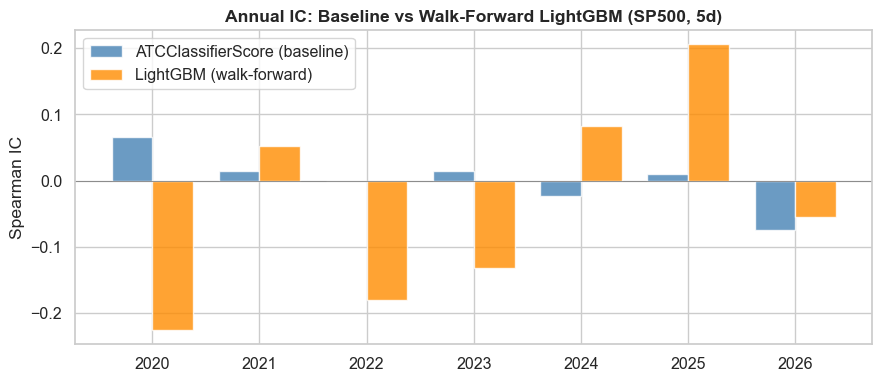

In [5]:
preds_df = pd.read_parquet(PREDS_PQ)
preds_df['entry_date'] = pd.to_datetime(preds_df['entry_date'])
preds_df['Year']       = preds_df['entry_date'].dt.year

# Merge ATC score for comparison
atc_ref  = feat_df[feat_df['entry_date'] >= '2020-01-01'][['DocID','ATCClassifierScore']]
preds_df = preds_df.merge(atc_ref, on='DocID', how='left')

def ic_by_year(df, signal_col, target_col='fwd_5d', univ_col='in_sp500'):
    sub = df[df[univ_col]].copy()
    return sub.groupby('Year').apply(
        lambda g: stats.spearmanr(
            g[signal_col].dropna(), g[target_col][g[signal_col].notna()]
        )[0] if g[signal_col].notna().sum() > 30 else np.nan
    ).rename(signal_col)

ic_model = ic_by_year(preds_df, 'lgbm_pred')
ic_atc   = ic_by_year(preds_df, 'ATCClassifierScore')

ic_compare = pd.concat([ic_atc, ic_model], axis=1)
print('Annual IC comparison (SP500, 5d horizon):')
print(ic_compare.round(4).to_string())

fig, ax = plt.subplots(figsize=(9, 4))
width   = 0.38
x       = np.arange(len(ic_compare))
ax.bar(x - width/2, ic_atc.values,   width, label='ATCClassifierScore (baseline)', color='steelblue', alpha=0.8)
ax.bar(x + width/2, ic_model.values, width, label='LightGBM (walk-forward)',       color='darkorange', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(ic_compare.index)
ax.axhline(0, color='grey', lw=0.6)
ax.set_title('Annual IC: Baseline vs Walk-Forward LightGBM (SP500, 5d)', fontweight='bold')
ax.set_ylabel('Spearman IC')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'ic_baseline_vs_lgbm.png', dpi=150, bbox_inches='tight')
plt.show()

## 5.5 Feature Importance (Last Fold)

Which features drive the model? We report the LightGBM gain-based importance from the **last** walk-forward fold (most data = most reliable). This feeds directly into the research PDF methodology section.

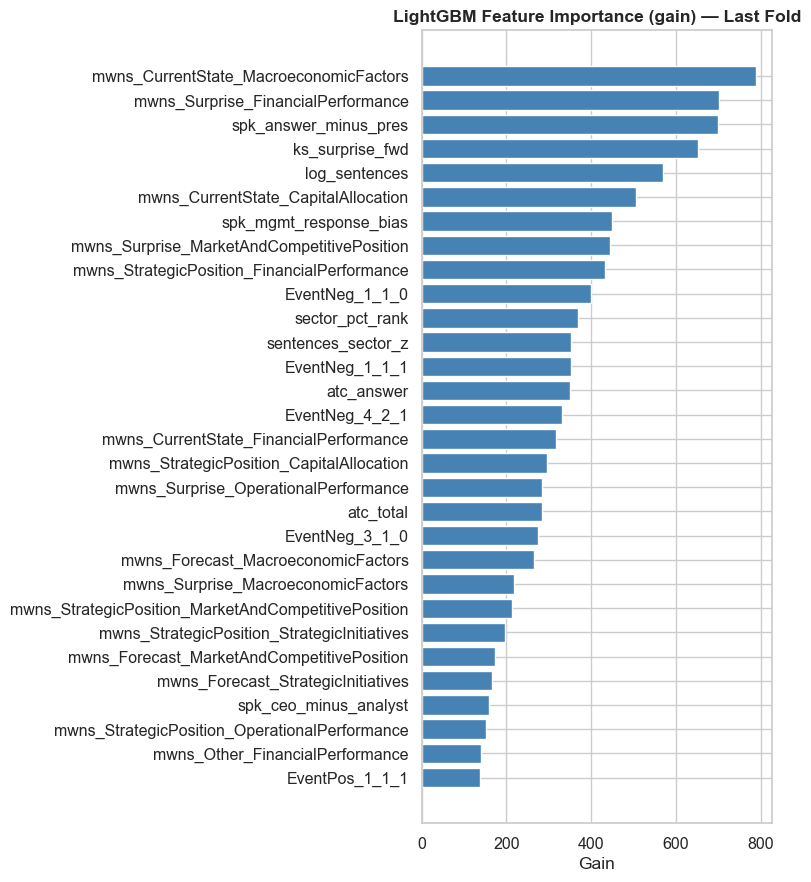

In [6]:
# Re-train last fold to extract feature importances (already done above, re-run last split)
train_mask, test_mask, _, _ = splits[-1]
train = feat_df[train_mask].dropna(subset=[TARGET])

X_train = train[FEATURE_COLS].fillna(0)
y_train = train[TARGET]

scaler   = StandardScaler()
X_tr_sc  = scaler.fit_transform(X_train)
mi_scores = mutual_info_regression(X_tr_sc, y_train, random_state=42)
top_idx   = np.argsort(mi_scores)[-N_FEATURES_SELECT:]
top_feat_names = np.array(FEATURE_COLS)[top_idx]

X_tr_sel  = X_tr_sc[:, top_idx]
model_last = lgb.LGBMRegressor(**best_params)
model_last.fit(X_tr_sel, y_train, callbacks=[lgb.log_evaluation(-1)])

importances = pd.Series(
    model_last.feature_importances_,
    index=top_feat_names
).sort_values(ascending=True).tail(30)

fig, ax = plt.subplots(figsize=(8, 9))
ax.barh(importances.index, importances.values, color='steelblue')
ax.set_title('LightGBM Feature Importance (gain) — Last Fold', fontweight='bold')
ax.set_xlabel('Gain')
plt.tight_layout()
plt.savefig(FIG_DIR / 'feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 5.6 Ensemble Signal: ATC Rank + LightGBM Rank

Both signals capture different aspects of the same call. We combine them by equal-weighting their **cross-sectional percentile ranks** on each entry date. This is simpler than learned weighting but harder to overfit.

In [7]:
# Rank both signals cross-sectionally on each entry_date, then average ranks
preds_df['atc_rank']   = preds_df.groupby('entry_date')['ATCClassifierScore'].rank(pct=True)
preds_df['lgbm_rank']  = preds_df.groupby('entry_date')['lgbm_pred'].rank(pct=True)
preds_df['ensemble']   = 0.5 * preds_df['atc_rank'] + 0.5 * preds_df['lgbm_rank']

# Quick IC comparison on SP500
sub = preds_df[preds_df['in_sp500']].dropna(subset=['fwd_5d'])
for sig in ['ATCClassifierScore', 'lgbm_pred', 'ensemble']:
    ic = stats.spearmanr(sub[sig].fillna(0), sub['fwd_5d'])[0]
    print(f'{sig:30s}  IC(5d) = {ic:.4f}')

# Save ensemble predictions
preds_df.to_parquet(PREDS_PQ, index=False)
print('\nEnsemble predictions saved.')

ATCClassifierScore              IC(5d) = 0.0138
lgbm_pred                       IC(5d) = 0.0140
ensemble                        IC(5d) = 0.0021

Ensemble predictions saved.
